In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import sys
print(sys.executable)

/home/iztihad/venvs/ml/bin/python


In [6]:
model_config = {
    "batch_size": 16,
    "input_size": 224,
    "learning_rate": 0.001,
    "epochs": 20,
    "pretrained":True
}

In [7]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])
}

train_dir = "../BanglaLekha_dataset_split/train"
val_dir = "../BanglaLekha_dataset_split/validation"
test_dir = "../BanglaLekha_dataset_split/test"


train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms["train"])
val_dataset = datasets.ImageFolder(root=val_dir, transform=data_transforms["val"])
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms["test"])

train_dataloader = DataLoader(train_dataset, batch_size=model_config["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=model_config["batch_size"], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=model_config["batch_size"], shuffle=False)

Training Data

In [18]:
train_classwise_freq = np.zeros(84, dtype=int)
for images, labels in train_dataloader:
    for x in labels:
        train_classwise_freq[x] += 1
train_basic_char_freq = sum(train_classwise_freq[0:50])
train_numeric_char_freq = sum(train_classwise_freq[50:60])
train_compound_char_freq = sum(train_classwise_freq[60:84])
train_basic_char_max = np.argmax(train_classwise_freq[0:50])
train_numeric_char_max = np.argmax(train_classwise_freq[50:60]) + 50
train_compound_char_max = np.argmax(train_classwise_freq[60:84]) + 60

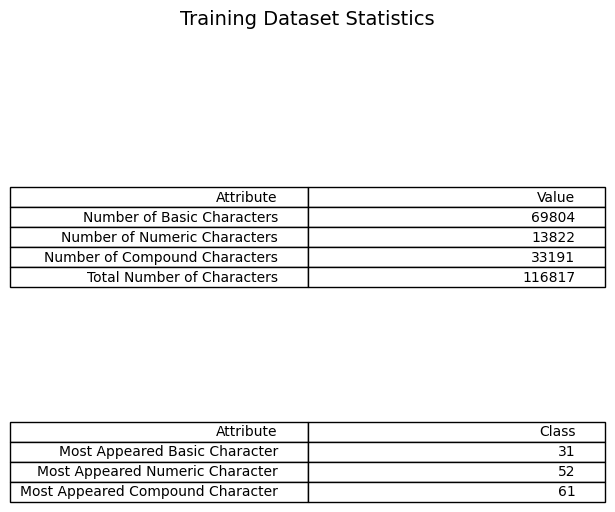

In [30]:
table_data = [["Attribute", "Value"]] 

table_data.append(["Number of Basic Characters", train_basic_char_freq])
table_data.append(["Number of Numeric Characters", train_numeric_char_freq])
table_data.append(["Number of Compound Characters", train_compound_char_freq])
table_data.append(["Total Number of Characters", sum(train_classwise_freq)])

fig, ax = plt.subplots()

ax.axis('off')

# Add title
ax.set_title("Training Dataset Statistics", fontsize=14, pad=20)

table = ax.table(
    cellText=table_data,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)



table_data2 = [["Attribute", "Class"]]

table_data2.append(["Most Appeared Basic Character", train_basic_char_max+1])
table_data2.append(["Most Appeared Numeric Character", train_numeric_char_max+1])
table_data2.append(["Most Appeared Compound Character", train_compound_char_max+1])

table = ax.table(
    cellText=table_data2,
    loc='bottom'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()


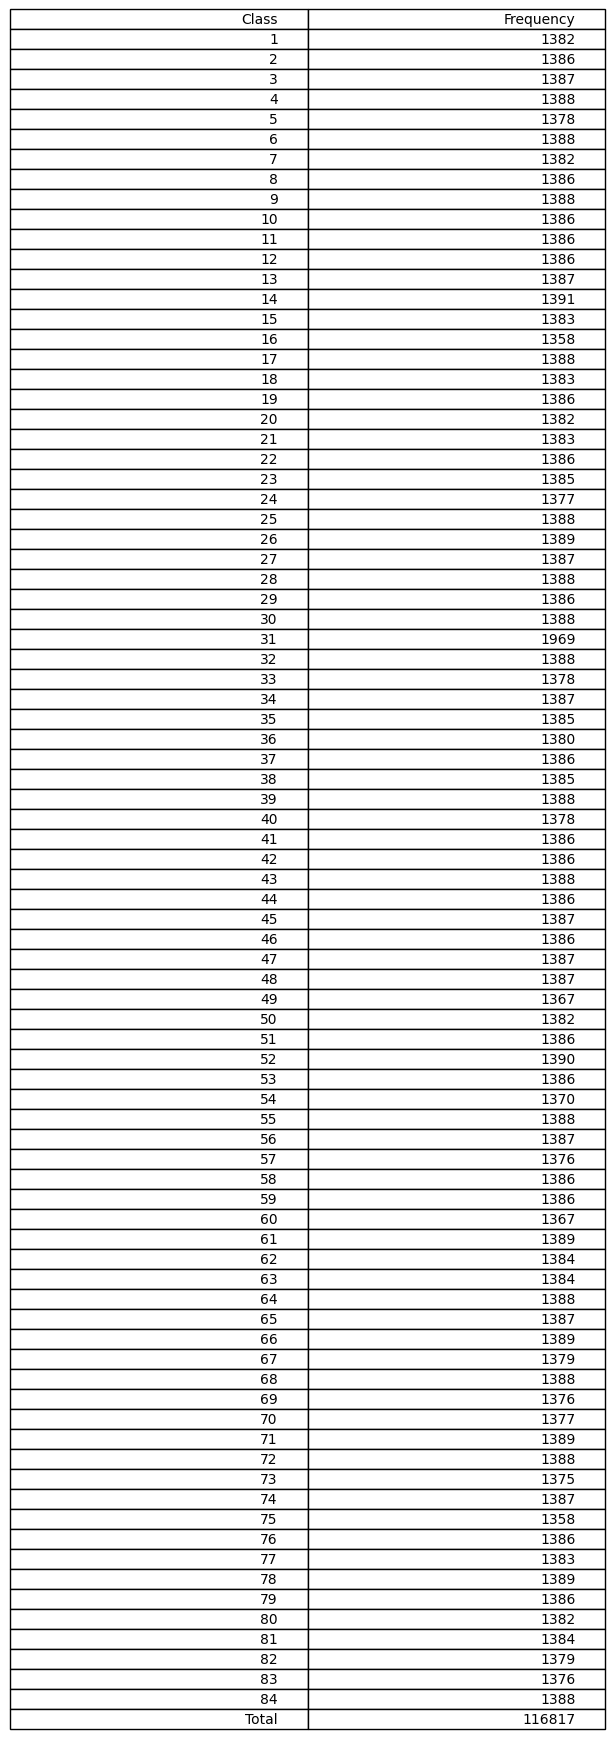

In [26]:


table_data = [["Class", "Frequency"]] 
for i, val in enumerate(train_classwise_freq):
    table_data.append([i+1, val])
table_data.append(["Total", sum(train_classwise_freq)])


fig, ax = plt.subplots()
ax.axis('off')
  
table = ax.table(cellText=table_data, loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()

Validation Data

In [27]:
val_classwise_freq = np.zeros(84, dtype=int)
for images, labels in val_dataloader:
    for x in labels:
        val_classwise_freq[x] += 1
val_basic_char_freq = sum(val_classwise_freq[0:50])
val_numeric_char_freq = sum(val_classwise_freq[50:60])
val_compound_char_freq = sum(val_classwise_freq[60:84])
val_basic_char_max = np.argmax(val_classwise_freq[0:50])
val_numeric_char_max = np.argmax(val_classwise_freq[50:60]) + 50
val_compound_char_max = np.argmax(val_classwise_freq[60:84]) + 60

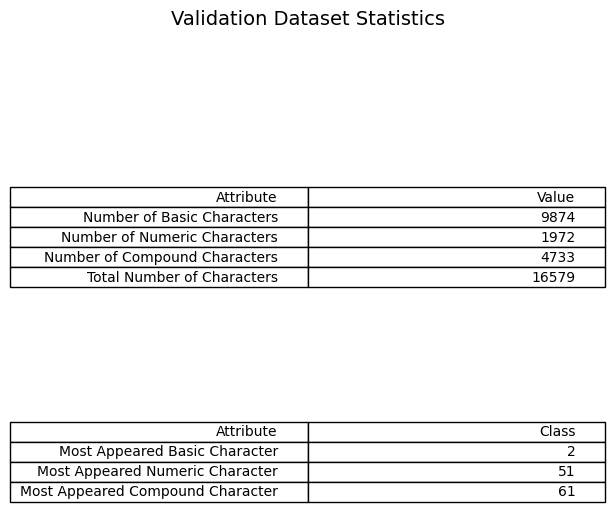

In [31]:
table_data = [["Attribute", "Value"]] 

table_data.append(["Number of Basic Characters", val_basic_char_freq])
table_data.append(["Number of Numeric Characters", val_numeric_char_freq])
table_data.append(["Number of Compound Characters", val_compound_char_freq])
table_data.append(["Total Number of Characters", sum(val_classwise_freq)])

fig, ax = plt.subplots()

ax.axis('off')

# Add title
ax.set_title("Validation Dataset Statistics", fontsize=14, pad=20)

table = ax.table(
    cellText=table_data,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)



table_data2 = [["Attribute", "Class"]]

table_data2.append(["Most Appeared Basic Character", val_basic_char_max+1])
table_data2.append(["Most Appeared Numeric Character", val_numeric_char_max+1])
table_data2.append(["Most Appeared Compound Character", val_compound_char_max+1])

table = ax.table(
    cellText=table_data2,
    loc='bottom'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()


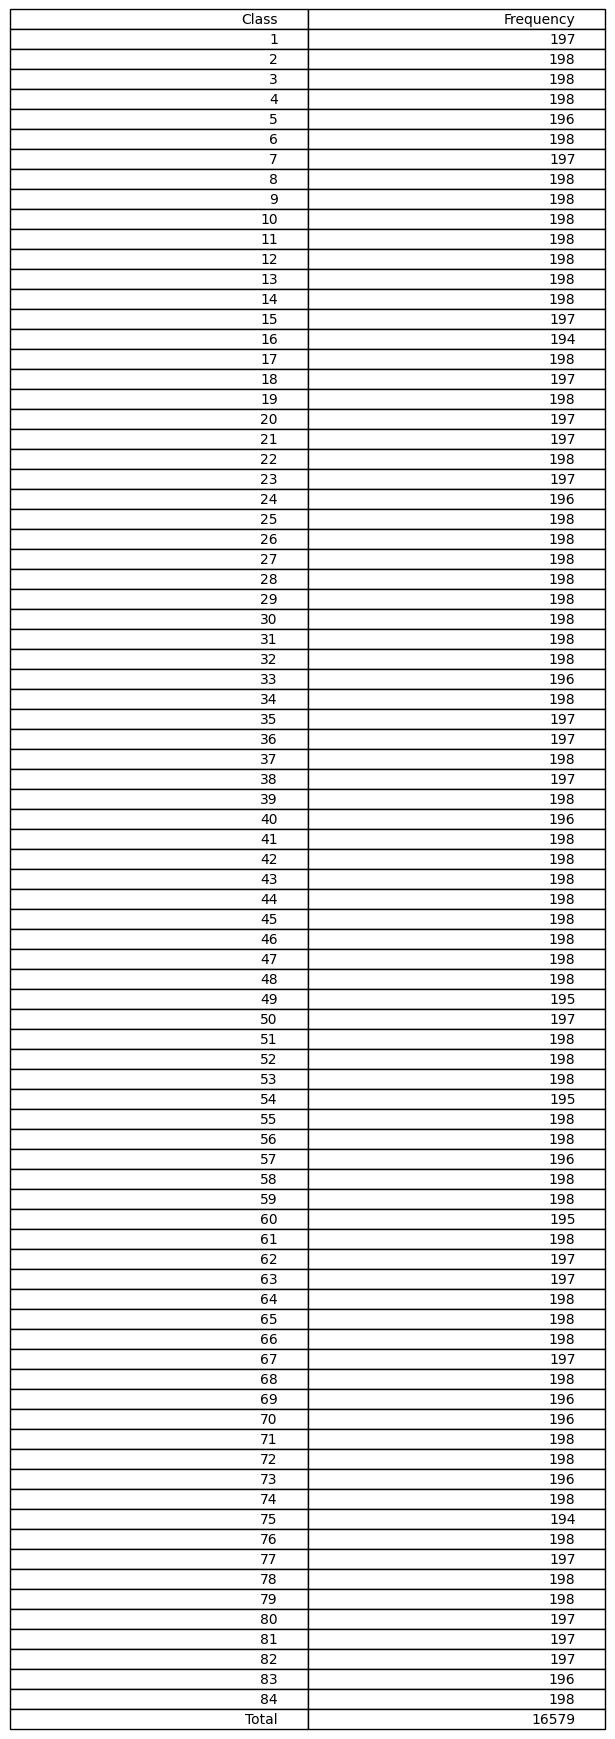

In [33]:

table_data = [["Class", "Frequency"]] 
for i, val in enumerate(val_classwise_freq):
    table_data.append([i+1, val])
table_data.append(["Total", sum(val_classwise_freq)])


fig, ax = plt.subplots()
ax.axis('off')
  
table = ax.table(cellText=table_data, loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()

Test Data

In [34]:
test_classwise_freq = np.zeros(84, dtype=int)
for images, labels in test_dataloader:
    for x in labels:
        test_classwise_freq[x] += 1
test_basic_char_freq = sum(test_classwise_freq[0:50])
test_numeric_char_freq = sum(test_classwise_freq[50:60])
test_compound_char_freq = sum(test_classwise_freq[60:84])
test_basic_char_max = np.argmax(test_classwise_freq[0:50])
test_numeric_char_max = np.argmax(test_classwise_freq[50:60]) + 50
test_compound_char_max = np.argmax(test_classwise_freq[60:84]) + 60

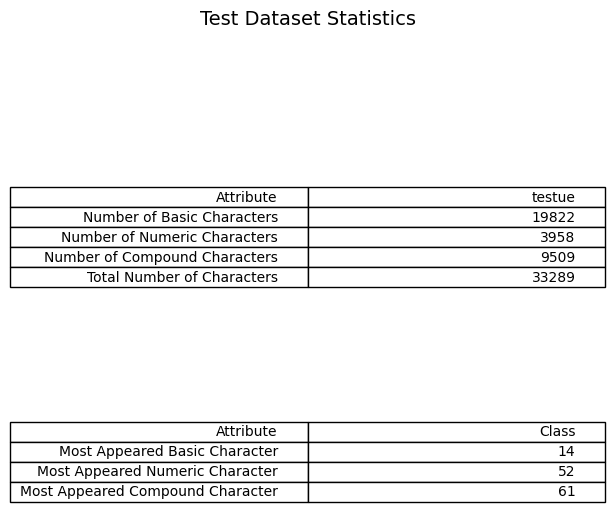

In [35]:
table_data = [["Attribute", "testue"]] 

table_data.append(["Number of Basic Characters", test_basic_char_freq])
table_data.append(["Number of Numeric Characters", test_numeric_char_freq])
table_data.append(["Number of Compound Characters", test_compound_char_freq])
table_data.append(["Total Number of Characters", sum(test_classwise_freq)])

fig, ax = plt.subplots()

ax.axis('off')

# Add title
ax.set_title("Test Dataset Statistics", fontsize=14, pad=20)

table = ax.table(
    cellText=table_data,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)



table_data2 = [["Attribute", "Class"]]

table_data2.append(["Most Appeared Basic Character", test_basic_char_max+1])
table_data2.append(["Most Appeared Numeric Character", test_numeric_char_max+1])
table_data2.append(["Most Appeared Compound Character", test_compound_char_max+1])

table = ax.table(
    cellText=table_data2,
    loc='bottom'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()


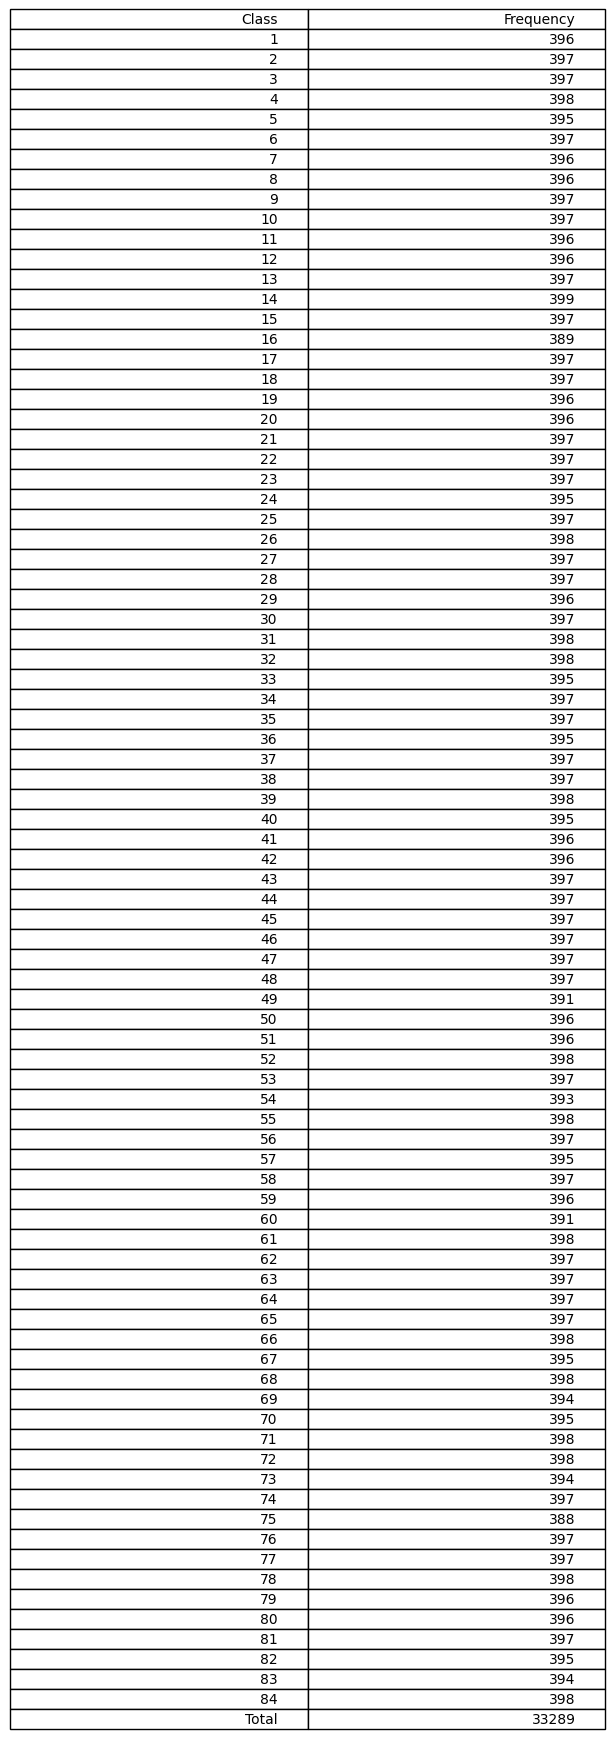

In [36]:

table_data = [["Class", "Frequency"]] 
for i, test in enumerate(test_classwise_freq):
    table_data.append([i+1, test])
table_data.append(["Total", sum(test_classwise_freq)])


fig, ax = plt.subplots()
ax.axis('off')
  
table = ax.table(cellText=table_data, loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()